# 07. Skills Pattern — 미들웨어 기반 온디맨드 컨텍스트 로딩

> 이 노트북은 **LangChain v1 미들웨어**(`SkillMiddleware`, `@wrap_model_call`)로 에이전트의 스킬을 동적으로 관리하는 방법을 다뤄요. Deep Agent SDK의 **SKILL.md + 백엔드(StateBackend/StoreBackend/FilesystemBackend)** 기반 스킬 관리는 **`10_Deep_Agents/05-Skills-Memory.ipynb`** 에서 따로 다뤄요 — 같은 Progressive Disclosure 개념을 다른 런타임에서 구현한 비교 학습으로 활용하세요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. Skills Pattern의 핵심 아이디어인 **Progressive Disclosure(점진적 공개)**를 설명할 수 있어요
2. `SkillMiddleware`를 구현해 에이전트가 필요한 스킬만 온디맨드로 로딩하게 만들 수 있어요
3. `load_skill` 도구와 `Command` 반환 패턴으로 상태를 업데이트하는 방법을 이해할 수 있어요
4. `CustomState`에 `skills_loaded` 필드를 추가해 스킬 로딩 여부를 추적할 수 있어요
5. SQL Assistant 예제를 통해 실전 Skills Pattern 전체 흐름을 구현할 수 있어요

## 사전 지식

- Part 5 `create_agent`와 `AgentState` 기본 구조
- Part 6 Middleware 기초 (`AgentMiddleware`, `wrap_model_call`)
- 이전 노트북 `06-Router-Pattern.ipynb` — 입력 분류 → 병렬 라우팅

## Skills Pattern 개요

> 📍 **Part 09에서의 위치**: `06-Router`가 **여러 에이전트에 병렬 분배**하는 패턴이었다면, 이 노트북은 **단일 에이전트의 능력을 런타임에 확장**하는 패턴이에요. 다음 `08-Hierarchical`은 다시 여러 에이전트의 **팀 계층** 구조로 확장돼요. 복잡도가 `분류·병렬(06) → 단일 에이전트의 동적 확장(07) → 팀 계층(08)` 순으로 올라간다고 보면 돼요.

**Skills Pattern**은 단일 에이전트가 모든 전문 지식을 처음부터 갖지 않고, **필요할 때만 해당 스킬을 로딩**하는 멀티 에이전트 패턴이에요.

하네스 관점에서 Skills는 **Inform** 계층이에요. 모델에게 모든 지식을 한꺼번에 밀어 넣는 대신, "이런 전문 지식이 필요할 때는 이 스킬을 불러라"라는 안내만 먼저 제공하고, 상세 절차는 필요할 때 주입합니다. 잘 설계된 스킬은 모델의 자유도를 줄여주는 **부드러운 Constrain** 역할도 해요.

> 🎯 **강의 포인트**: Skills Pattern은 **스마트폰 앱 스토어**와 같아요. 스마트폰(에이전트)을 처음 사면 기본 앱만 깔려 있어요. 사진 편집이 필요하면 편집 앱을, 음악이 필요하면 음악 앱을 **필요할 때만** 설치해요. 모든 앱을 미리 깔아놓으면 용량(토큰)이 부족하니까요. Skills Pattern도 마찬가지로, 에이전트가 SQL 작업이 필요하면 `load_skill('sql')` 호출로 SQL 전문 지식을 그때 주입받아요.

기존 Subagents 패턴과의 핵심 차이를 먼저 살펴볼게요.

| 비교 항목 | Subagents 패턴 | Skills Pattern |
|-----------|---------------|----------------|
| **에이전트 수** | 여러 개 (각 전문가) | 단 하나 |
| **전문 지식 위치** | 각 에이전트의 시스템 프롬프트 | 스킬 저장소(외부) |
| **컨텍스트 관리** | 각 에이전트가 독립적 컨텍스트 보유 | 필요한 스킬만 로딩해 누적 |
| **LLM 호출 수** | 많음 (에이전트별 독립 호출) | 적음 (한 에이전트가 연속 처리) |
| **토큰 효율** | 에이전트별 분산 | 단일 컨텍스트 집중 |
| **비유** | 전문의가 여러 명 있는 병원 | 만능 의사가 의학 교과서를 필요할 때 펼쳐보는 것 |

### Progressive Disclosure(점진적 공개)

Skills Pattern의 핵심 원리는 **설명(description)만 처음에 제공하고, 상세 내용(content)은 필요할 때 로딩**하는 것이에요.

```
초기 시스템 프롬프트:
  skill_1: SQL 쿼리 작성 전문 스킬 (use load_skill('sql') to load)
  skill_2: 데이터 분석 전문 스킬 (use load_skill('analytics') to load)

에이전트가 'sql' 스킬이 필요하다고 판단하면:
  → load_skill('sql') 호출
  → 상태에 SQL 전문 지식 추가
  → 이후 호출부터 SQL 전문가처럼 동작
```

> 🔑 **핵심 개념**: 모든 스킬을 시스템 프롬프트에 넣으면 토큰 낭비예요. Skills Pattern은 "설명"만 먼저 주고, 실제 전문 지식은 에이전트가 요청할 때만 주입해요. 이것이 Progressive Disclosure(점진적 공개)예요.

### 시스템 아키텍처

```mermaid
flowchart TD
    U(["사용자 입력<br/>User Input"]) --> A

    subgraph AGENT["단일 에이전트"]
        A(["에이전트<br/>(스킬 목록 보유)"]) -->|스킬 필요 판단| LS
        LS(["load_skill 호출<br/>(Tool)"]) -->|스킬 내용 주입| SM
        SM(["SkillMiddleware<br/>(시스템 프롬프트 업데이트)"]) --> A
    end

    A -->|스킬 보유 후 실행| T(["전문 도구 실행<br/>(SQL, Analytics...)"])
    T --> A
    A --> OUT(["최종 응답<br/>Final Response"])

    SB(["스킬 저장소<br/>Skill Store"]) -->|content 반환| LS

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef error fill:#f8d7da,stroke:#dc3545,color:#721c24

    class U input
    class A,SM process
    class LS,T process
    class OUT output
    class SB storage
```

### 핵심 구성 요소

| 구성 요소 | 역할 | 핵심 포인트 |
|-----------|------|-------------|
| **Skill TypedDict** | 스킬 메타데이터 구조 | `name`, `description`, `content` 세 필드 |
| **SkillMiddleware** | 모델 호출 전 스킬 설명 주입 | `wrap_model_call`로 시스템 프롬프트에 추가 |
| **load_skill 도구** | 스킬 전체 내용을 상태에 추가 | `Command`로 `skills_loaded` 상태 업데이트 |
| **CustomState** | 로딩된 스킬 목록 추적 | `AgentState` + `skills_loaded` 필드 |

## 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에서 OPENAI_API_KEY 등을 불러와요
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택 사항)
# ---------------------------------------------------
# 실행 추적을 원하면 아래 주석을 해제하세요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "Skills-Pattern-Tutorial"

## 모델 설정

LangChain V1의 `init_chat_model`로 기본 모델을 초기화해요.

In [3]:
# ---------------------------------------------------
# 모델 초기화
# ---------------------------------------------------
from langchain.chat_models import init_chat_model

# 기본 모델: gpt-4o-mini (비용 효율, 학생 접근성)
# 다른 모델로 변경하려면:
#   Anthropic: "anthropic:claude-sonnet-4-5"
#   Ollama 로컬: "ollama:llama3"
model = init_chat_model("openai:gpt-4o-mini")
# 모델 초기화 완료: gpt-4o-mini

## 1. Skill 데이터 구조 정의

스킬은 세 가지 필드로 구성된 `TypedDict`이에요.

| 필드 | 타입 | 역할 |
|------|------|------|
| `name` | `str` | 스킬 식별자 (load_skill 호출 시 사용) |
| `description` | `str` | 시스템 프롬프트에 항상 포함 (설명만) |
| `content` | `str` | load_skill 호출 시에만 주입 (상세 전문 지식) |

> 🔑 **핵심 개념**: `description`은 에이전트가 **"이 스킬이 존재한다"**는 것을 알게 해줘요. `content`는 에이전트가 실제로 스킬을 쓸 수 있는 전문 지식이에요. 초기에는 설명만 주고, 필요하면 내용을 로딩해요.

> 💡 **실무 팁**: `description`은 짧고 명확하게 (1~2문장), `content`는 풍부한 전문 지식을 담아요. 예를 들어 SQL 스킬의 `content`에는 회사의 DB 스키마, 자주 쓰는 쿼리 패턴, 주의사항 등을 넣을 수 있어요.

> 🔐 **주의**: 스킬은 모델 행동을 바꾸는 하네스 입력이에요. 출처가 불분명한 스킬을 그대로 로딩하지 말고, 버전 관리·리뷰·중복 이름 방지·권한 경계를 함께 관리하세요.

In [4]:
# ---------------------------------------------------
# Skill TypedDict 정의
# ---------------------------------------------------
from typing_extensions import TypedDict, NotRequired


class Skill(TypedDict):
    """스킬 메타데이터 구조

    name: 스킬 고유 식별자 (load_skill 호출 시 사용)
    description: 시스템 프롬프트에 항상 포함되는 짧은 설명
    content: load_skill 호출 후에만 주입되는 상세 전문 지식
    """

    name: str           # 스킬 이름 (예: 'sql', 'analytics')
    description: str    # 짧은 설명 — 항상 시스템 프롬프트에 포함
    content: str        # 상세 전문 지식 — load_skill 호출 후 주입


# Skill TypedDict 정의 완료
#   - name: 스킬 식별자
#   - description: 항상 노출되는 짧은 설명
#   - content: 요청 시에만 로딩되는 상세 지식

## 2. SQL Assistant 스킬 정의

실전 예제로 **SQL Assistant**를 만들어볼게요. 가상의 e-commerce DB를 다루는 두 가지 스킬을 정의해요.

| 스킬 | 설명 | content 내용 |
|------|------|----------------|
| `sql` | SQL 쿼리 작성 전문 스킬 | DB 스키마, 쿼리 패턴, 주의사항 |
| `analytics` | 데이터 분석 및 해석 스킬 | 분석 방법론, KPI 계산 공식 |

> ⚠️ **자주 하는 실수**: `description`에 상세 내용을 모두 넣으면 Progressive Disclosure의 이점이 사라져요. `description`은 딱 한 줄, 언제 이 스킬을 써야 하는지만 적어요.

In [ ]:
# ---------------------------------------------------
# SQL Assistant 스킬 정의
# ---------------------------------------------------

# SQL 스킬: DB 스키마와 쿼리 작성 전문 지식
sql_skill: Skill = {
    "name": "sql",
    # description: 에이전트가 항상 볼 수 있는 짧은 설명 (1~2 문장)
    "description": (
        "SQL 쿼리 작성 전문 스킬. "
        "e-commerce DB 스키마와 쿼리 패턴을 포함해요. "
        "SQL 쿼리 작성이 필요할 때 load_skill('sql')을 호출하세요."
    ),
    # content: load_skill 호출 후에만 주입되는 상세 전문 지식
    "content": """
## SQL 전문 스킬: E-Commerce DB

### 데이터베이스 스키마

```sql
-- 사용자 테이블
users (user_id INT PK, name VARCHAR, email VARCHAR, created_at DATETIME, country VARCHAR)

-- 상품 테이블  
products (product_id INT PK, name VARCHAR, category VARCHAR, price DECIMAL, stock INT)

-- 주문 테이블
orders (order_id INT PK, user_id INT FK, created_at DATETIME, status VARCHAR, total_amount DECIMAL)

-- 주문 상세 테이블
order_items (item_id INT PK, order_id INT FK, product_id INT FK, quantity INT, unit_price DECIMAL)
```

### 자주 사용하는 쿼리 패턴

이 실습 데이터베이스는 **SQLite**예요. MySQL의 `DATE_FORMAT` 같은 함수는 사용할 수 없고, 월별 집계는 `strftime('%Y-%m', created_at)`을 사용하세요.

```sql
-- 월별 매출 집계 (SQLite)
SELECT strftime('%Y-%m', created_at) AS month,
       SUM(total_amount) AS revenue,
       COUNT(*) AS order_count
FROM orders
WHERE status = 'completed'
GROUP BY strftime('%Y-%m', created_at)
ORDER BY month;

-- 상위 고객 조회
SELECT u.user_id,
       u.name,
       COUNT(o.order_id) AS total_orders,
       SUM(o.total_amount) AS total_spent
FROM users u
JOIN orders o ON u.user_id = o.user_id
WHERE o.status = 'completed'
GROUP BY u.user_id, u.name
ORDER BY total_spent DESC
LIMIT 10;
```

### 주의사항
- SQLite 문법으로 작성하세요. `DATE_FORMAT`, `INTERVAL`, `NOW()` 같은 MySQL 전용 문법은 사용하지 마세요.
- 같은 `SELECT` 절에서 방금 만든 별칭을 다른 식에서 바로 참조하지 마세요. 필요한 경우 서브쿼리나 CTE를 사용하세요.
- 항상 WHERE 절로 날짜 범위를 제한하세요 (전체 스캔 방지)
- order_items와 orders를 JOIN할 때 인덱스 컬럼(order_id)을 사용하세요
- REAL/DECIMAL 타입 집계 시 ROUND(값, 2)로 소수점을 정리하세요
""",
}

# 분석 스킬: 데이터 해석과 KPI 계산 전문 지식
analytics_skill: Skill = {
    "name": "analytics",
    "description": (
        "데이터 분석 및 비즈니스 지표 해석 스킬. "
        "KPI 계산, 트렌드 분석, 인사이트 도출을 포함해요. "
        "데이터 해석이나 분석 보고서 작성이 필요하면 load_skill('analytics')를 호출하세요."
    ),
    "content": """
## 데이터 분석 전문 스킬

### 핵심 KPI 계산 공식

- **전환율(CVR)** = 구매자 수 / 방문자 수 × 100
- **평균 주문 금액(AOV)** = 총 매출 / 총 주문 수
- **고객 생애 가치(CLV)** = AOV × 구매 빈도 × 고객 수명(년)
- **재구매율** = 2회 이상 구매 고객 / 전체 구매 고객 × 100
- **카테고리 매출 비중** = 카테고리 매출 / 전체 매출 × 100

### 분석 보고서 구조

1. **요약(Summary)**: 핵심 수치 3개 이내
2. **현황(Status)**: 주요 지표 현재 값과 전기 대비
3. **트렌드(Trend)**: 시계열 변화와 패턴
4. **인사이트(Insight)**: 데이터가 의미하는 것
5. **제언(Recommendation)**: 다음 액션

### 해석 가이드라인
- 단순 수치보다 전기 대비 변화율(%)로 표현하세요
- 이상치(outlier)는 반드시 언급하고 원인을 추정하세요
- "데이터에 따르면"으로 시작해 근거 기반 서술을 하세요
""",
}

# 모든 스킬을 딕셔너리로 관리 (name → Skill 매핑)
SKILLS_REGISTRY: dict[str, Skill] = {
    skill["name"]: skill
    for skill in [sql_skill, analytics_skill]
}

print(f"스킬 레지스트리 구성 완료: {list(SKILLS_REGISTRY.keys())}")
# 각 스킬의 description (에이전트가 항상 보는 내용):
for name, skill in SKILLS_REGISTRY.items():
    print(f"  [{name}]: {skill['description'][:60]}...")

## 3. CustomState 정의

Skills Pattern은 `AgentState`를 확장한 `CustomState`를 사용해요. 로딩된 스킬 목록을 추적하기 위한 `skills_loaded` 필드가 추가돼요.

```python
class CustomState(AgentState):
    # Annotated[list[str], operator.add]: 여러 스텝에서 동시에 업데이트해도 안전하게 병합
    skills_loaded: Annotated[list[str], operator.add]
```

> 🔑 **핵심 개념**: `Annotated[list[str], operator.add]`는 LangGraph에게 이 필드의 **리듀서(reducer)**를 `operator.add`(리스트 이어붙이기)로 사용하라고 알려줘요. `load_skill` 도구가 `["sql"]`을 반환하면 LangGraph가 자동으로 기존 목록에 이어붙여요. 초기 상태에서 빈 리스트 `[]`로 시작해요.

> 💡 **실무 팁**: `skills_loaded`를 추적하면 **같은 스킬을 중복 로딩하는 것을 방지**할 수 있어요. 에이전트가 이미 로딩된 스킬을 다시 로딩하려 하면 `load_skill`이 에러를 반환해 불필요한 API 호출을 막아요.

In [6]:
# ---------------------------------------------------
# CustomState 정의
# ---------------------------------------------------
import operator
from typing import Annotated
from langchain.agents import AgentState
from typing_extensions import NotRequired


class CustomState(AgentState):
    """Skills Pattern을 위한 확장 상태

    AgentState (messages 포함)를 상속하고
    skills_loaded 필드를 추가해 로딩된 스킬을 추적해요.

    Annotated[list[str], operator.add]를 사용해
    여러 스텝에서 동시에 skills_loaded를 업데이트해도 충돌이 없어요.
    LangGraph가 리스트를 자동으로 합쳐줘요 (append 방식).
    """

    # 로딩된 스킬 이름 목록
    # Annotated[list, operator.add]: 여러 노드에서 동시에 업데이트해도 안전하게 병합됩니다
    skills_loaded: Annotated[list[str], operator.add]


# CustomState 정의 완료
#   상속: AgentState (messages 포함)
#   추가 필드: skills_loaded (Annotated[list[str], operator.add])
#   → operator.add 리듀서: 여러 업데이트 시 리스트 자동 병합

## 4. load_skill 도구 구현

`load_skill`은 Skills Pattern의 핵심 도구예요. 에이전트가 이 도구를 호출하면:

1. 스킬 레지스트리에서 해당 스킬의 `content`를 찾아요
2. `Command`를 반환해 `skills_loaded` 상태를 업데이트해요
3. `ToolMessage`로 스킬 내용을 에이전트 컨텍스트에 주입해요

### Command 반환 패턴

일반 도구는 문자열이나 딕셔너리를 반환해요. `load_skill`은 특별히 `Command`를 반환해 **상태를 직접 업데이트**할 수 있어요.

```python
return Command(
    update={
        "skills_loaded": current_loaded + [skill_name],  # 상태 업데이트
        "messages": [ToolMessage(...)],                   # 에이전트에게 내용 전달
    }
)
```

> 🎯 **강의 포인트**: 일반 도구는 `ToolMessage`만 반환하지만, `Command`를 반환하면 도구 호출만으로 `CustomState`의 `skills_loaded` 같은 커스텀 필드를 업데이트할 수 있어요. 이것이 Skills Pattern의 핵심 메커니즘이에요.

> ⚠️ **자주 하는 실수**: `Command`를 반환하는 도구는 `InjectedToolCallId`로 tool_call_id를 받아야 해요. 그래야 올바른 `ToolMessage`를 생성할 수 있어요.

In [7]:
# ---------------------------------------------------
# load_skill 도구 구현
# ---------------------------------------------------
from typing import Annotated
from langchain.tools import tool
from langchain.messages import ToolMessage
from langgraph.types import Command
from langchain_core.tools import InjectedToolCallId


@tool
def load_skill(
    skill_name: Annotated[str, "로딩할 스킬 이름 (예: 'sql', 'analytics')"],
    tool_call_id: Annotated[str, InjectedToolCallId],  # 도구 호출 ID (자동 주입)
) -> Command:
    """스킬을 온디맨드로 로딩해요.

    스킬 레지스트리에서 해당 스킬의 전문 지식(content)을 가져와
    에이전트 컨텍스트에 주입해요. 스킬 로딩 후 해당 전문가처럼 동작할 수 있어요.
    이미 로딩된 스킬을 다시 로딩하면 에러를 반환해요.
    """
    # 존재하지 않는 스킬 요청 처리
    if skill_name not in SKILLS_REGISTRY:
        available = list(SKILLS_REGISTRY.keys())
        error_msg = f"스킬 '{skill_name}'을 찾을 수 없어요. 사용 가능한 스킬: {available}"
        return Command(
            update={
                "messages": [
                    ToolMessage(
                        content=error_msg,
                        tool_call_id=tool_call_id,
                    )
                ]
            }
        )

    # 스킬 레지스트리에서 content 가져오기
    skill = SKILLS_REGISTRY[skill_name]
    skill_content = skill["content"]

    # Command로 반환: 상태 업데이트 + ToolMessage 주입
    # skills_loaded에 [skill_name]을 추가 — operator.add 리듀서가 기존 목록에 이어붙여줘요
    return Command(
        update={
            # 로딩된 스킬 이름을 목록에 추가 (operator.add 리듀서로 기존 목록에 병합됨)
            "skills_loaded": [skill_name],
            # ToolMessage로 스킬 내용을 에이전트 컨텍스트에 주입
            "messages": [
                ToolMessage(
                    content=(
                        f"스킬 '{skill_name}' 로딩 완료.\n\n"
                        f"{skill_content}"
                    ),
                    tool_call_id=tool_call_id,
                    name=f"load_skill_{skill_name}",
                )
            ],
        }
    )


# load_skill 도구 정의 완료
#   - skill_name: 로딩할 스킬 이름
#   - tool_call_id: InjectedToolCallId로 자동 주입
#   - 반환: Command (상태 업데이트 + ToolMessage 포함)
#   - skills_loaded: [skill_name] → operator.add로 기존 목록에 병합

## 5. SkillMiddleware 구현

`SkillMiddleware`는 에이전트가 LLM을 호출하기 직전에 시스템 프롬프트를 동적으로 업데이트해요.

### 동작 원리

```
에이전트 LLM 호출 직전
  ↓
SkillMiddleware.wrap_model_call 실행
  ↓
현재 상태에서 skills_loaded 확인
  ↓
아직 로딩 안 된 스킬의 description만 시스템 프롬프트에 추가
  ↓
"load_skill('sql')로 SQL 스킬을 로딩하세요" 형태로 안내
  ↓
업데이트된 시스템 프롬프트로 LLM 호출
```

> 🔑 **핵심 개념**: `SkillMiddleware`는 `AgentMiddleware`를 상속해요. `wrap_model_call` 메서드를 오버라이드해 모델 호출 전에 시스템 프롬프트를 가로채고 수정해요. 이것이 Middleware 패턴의 핵심이에요.

> 💡 **실무 팁**: `SkillMiddleware`는 이미 로딩된 스킬은 description에서 제외해요. 한번 로딩한 스킬의 설명을 반복 표시하면 프롬프트 공간을 낭비하기 때문이에요.

> 🎯 **하네스 관점**: description은 단순 설명문이 아니라 모델이 어떤 절차를 불러올지 결정하는 **작은 라우터**예요. 두 스킬의 description이 비슷하면 모델이 잘못 고를 수 있으니, 이름과 설명을 겹치지 않게 작성하세요.

In [8]:
# ---------------------------------------------------
# SkillMiddleware 구현
# ---------------------------------------------------
from typing import Callable
from langchain_core.messages import SystemMessage, BaseMessage, AnyMessage
from langchain.agents.middleware import AgentMiddleware
from langchain.agents.middleware.types import ModelRequest, ModelResponse


class SkillMiddleware(AgentMiddleware):
    """스킬 설명을 시스템 프롬프트에 동적으로 주입하는 미들웨어

    에이전트가 LLM을 호출하기 직전에 실행돼요.
    아직 로딩하지 않은 스킬의 description을 시스템 프롬프트에 추가해서
    에이전트가 필요할 때 load_skill을 호출하도록 유도해요.
    """

    def __init__(self, skills: list[Skill]):
        """미들웨어 초기화

        Args:
            skills: 관리할 스킬 목록
        """
        self.skills = skills

    def wrap_model_call(
        self,
        request: ModelRequest,
        handler: Callable[[ModelRequest], ModelResponse],
    ) -> ModelResponse:
        """모델 호출을 가로채 시스템 프롬프트에 스킬 설명을 추가해요.

        이미 로딩된 스킬은 제외하고, 아직 로딩하지 않은 스킬만 안내해요.
        """
        # 현재 로딩된 스킬 목록 조회 (없으면 빈 목록)
        state = request.state if hasattr(request, 'state') else {}
        loaded_skills: list[str] = state.get("skills_loaded", []) if isinstance(state, dict) else []

        # 아직 로딩하지 않은 스킬 필터링
        available_skills = [
            skill for skill in self.skills
            if skill["name"] not in loaded_skills
        ]

        # 주입할 스킬 설명 섹션 생성
        if available_skills:
            skill_descriptions = "\n".join(
                f"- {skill['name']}: {skill['description']}"
                for skill in available_skills
            )
            skill_section = (
                "\n\n## 사용 가능한 스킬\n"
                "다음 스킬을 load_skill() 도구로 로딩해서 활용할 수 있어요:\n"
                f"{skill_descriptions}"
            )
        else:
            # 모든 스킬이 로딩된 경우 안내 없음
            skill_section = ""

        if skill_section:
            # 기존 system_prompt에 스킬 섹션 추가
            existing_prompt = request.system_prompt or ""
            modified_request = request.override(
                system_prompt=existing_prompt + skill_section
            )
            return handler(modified_request)

        return handler(request)


# SkillMiddleware 정의 완료
#   - wrap_model_call: LLM 호출 전 시스템 프롬프트에 스킬 설명 주입
#   - 로딩된 스킬은 자동으로 description에서 제외

## 6. SQL Assistant 에이전트 생성

이제 모든 컴포넌트를 조합해 SQL Assistant 에이전트를 만들어요.

### SQL 실행 도구

실습을 위해 간단한 인메모리 SQLite DB를 만들고, 실제로 SQL을 실행할 수 있는 도구를 정의해요.

In [9]:
# ---------------------------------------------------
# SQLite 인메모리 DB 설정 및 SQL 실행 도구
# ---------------------------------------------------
import sqlite3
from langchain.tools import tool

# 인메모리 SQLite DB 생성 및 샘플 데이터 삽입
conn = sqlite3.connect(":memory:", check_same_thread=False)
cursor = conn.cursor()

# 테이블 생성
cursor.executescript("""
CREATE TABLE users (
    user_id INTEGER PRIMARY KEY,
    name TEXT,
    email TEXT,
    country TEXT,
    created_at TEXT
);

CREATE TABLE products (
    product_id INTEGER PRIMARY KEY,
    name TEXT,
    category TEXT,
    price REAL,
    stock INTEGER
);

CREATE TABLE orders (
    order_id INTEGER PRIMARY KEY,
    user_id INTEGER,
    created_at TEXT,
    status TEXT,
    total_amount REAL,
    FOREIGN KEY (user_id) REFERENCES users(user_id)
);

CREATE TABLE order_items (
    item_id INTEGER PRIMARY KEY,
    order_id INTEGER,
    product_id INTEGER,
    quantity INTEGER,
    unit_price REAL,
    FOREIGN KEY (order_id) REFERENCES orders(order_id),
    FOREIGN KEY (product_id) REFERENCES products(product_id)
);
""")

# 샘플 데이터 삽입
cursor.executemany(
    "INSERT INTO users VALUES (?, ?, ?, ?, ?)",
    [
        (1, "김민준", "minjun@example.com", "KR", "2024-01-15"),
        (2, "이서연", "seoyeon@example.com", "KR", "2024-02-20"),
        (3, "박지호", "jiho@example.com", "US", "2024-03-10"),
        (4, "최수아", "sua@example.com", "KR", "2024-04-05"),
        (5, "정도윤", "doyun@example.com", "JP", "2024-05-18"),
    ]
)

cursor.executemany(
    "INSERT INTO products VALUES (?, ?, ?, ?, ?)",
    [
        (1, "무선 이어폰", "전자제품", 89000, 150),
        (2, "스마트워치", "전자제품", 250000, 80),
        (3, "운동화", "패션", 120000, 200),
        (4, "백팩", "패션", 75000, 120),
        (5, "텀블러", "생활용품", 35000, 300),
    ]
)

cursor.executemany(
    "INSERT INTO orders VALUES (?, ?, ?, ?, ?)",
    [
        (1, 1, "2024-06-01", "completed", 178000),
        (2, 2, "2024-06-05", "completed", 250000),
        (3, 1, "2024-07-10", "completed", 120000),
        (4, 3, "2024-07-15", "completed", 35000),
        (5, 4, "2024-08-01", "completed", 324000),
        (6, 2, "2024-08-20", "completed", 89000),
        (7, 5, "2024-09-03", "completed", 195000),
        (8, 1, "2024-09-15", "cancelled", 75000),
    ]
)

cursor.executemany(
    "INSERT INTO order_items VALUES (?, ?, ?, ?, ?)",
    [
        (1, 1, 1, 2, 89000),
        (2, 2, 2, 1, 250000),
        (3, 3, 3, 1, 120000),
        (4, 4, 5, 1, 35000),
        (5, 5, 2, 1, 250000),
        (6, 5, 4, 1, 74000),
        (7, 6, 1, 1, 89000),
        (8, 7, 3, 1, 120000),
        (9, 7, 5, 2, 35000),
        (10, 8, 4, 1, 75000),
    ]
)

conn.commit()


@tool
def execute_sql(
    query: Annotated[str, "실행할 SQL 쿼리. SELECT 문만 허용돼요."]
) -> str:
    """SQL 쿼리를 실행하고 결과를 반환해요. SELECT 문만 허용해요."""
    # 안전을 위해 SELECT만 허용
    query_stripped = query.strip().upper()
    if not query_stripped.startswith("SELECT"):
        return "오류: SELECT 쿼리만 허용돼요."

    try:
        cur = conn.cursor()
        cur.execute(query)
        rows = cur.fetchall()
        columns = [desc[0] for desc in cur.description]

        if not rows:
            return "결과 없음"

        # 결과를 읽기 좋은 텍스트 테이블로 포맷
        header = " | ".join(columns)
        separator = "-" * len(header)
        result_rows = [" | ".join(str(v) for v in row) for row in rows]
        return "\n".join([header, separator] + result_rows[:20])  # 최대 20행 반환

    except Exception as e:
        return f"쿼리 실행 오류: {e}"


# SQLite DB 생성 완료 (인메모리)
# 테이블: users, products, orders, order_items
# execute_sql 도구 정의 완료

In [10]:
# ---------------------------------------------------
# DB 설정 확인 — execute_sql 도구 테스트
# ---------------------------------------------------
# 샘플 데이터가 잘 삽입됐는지 확인해요
result = execute_sql.invoke({"query": "SELECT name, category, price FROM products ORDER BY price DESC"})
print("=== 상품 목록 ===\n", result)

print()

result = execute_sql.invoke({"query": "SELECT COUNT(*) as total_orders, SUM(total_amount) as revenue FROM orders WHERE status = 'completed'"})
print("=== 완료된 주문 통계 ===\n", result)

=== 상품 목록 ===
 name | category | price
-----------------------
스마트워치 | 전자제품 | 250000.0
운동화 | 패션 | 120000.0
무선 이어폰 | 전자제품 | 89000.0
백팩 | 패션 | 75000.0
텀블러 | 생활용품 | 35000.0

=== 완료된 주문 통계 ===
 total_orders | revenue
----------------------
7 | 1191000.0


## 7. SQL Assistant 에이전트 완성

모든 컴포넌트를 조합해 Skills Pattern을 적용한 SQL Assistant를 만들어요.

### 에이전트 구성

| 컴포넌트 | 역할 |
|----------|------|
| `SkillMiddleware` | LLM 호출 전 스킬 description 주입 |
| `load_skill` 도구 | 스킬 content 온디맨드 로딩 |
| `execute_sql` 도구 | 실제 SQL 실행 |
| `CustomState` | 스킬 로딩 상태 추적 |

> 🎯 **강의 포인트**: 에이전트의 시스템 프롬프트에는 SQL 전문 지식이 없어요. 대신 "SQL 스킬이 있고 필요하면 로딩할 수 있다"는 안내만 있어요. 에이전트가 SQL 작업이 필요하다고 판단하면 `load_skill('sql')`을 호출하고, 그 다음 호출부터 SQL 전문가처럼 동작해요.

In [ ]:
# ---------------------------------------------------
# SQL Assistant 에이전트 생성
# ---------------------------------------------------
from langchain.agents import create_agent
from langgraph.checkpoint.memory import MemorySaver

# 에이전트 시스템 프롬프트
# SQL 전문 지식은 없고, load_skill로 로딩해야 한다는 안내만 있어요
system_prompt = """당신은 e-commerce 데이터 분석을 도와주는 어시스턴트예요.

SQL 쿼리 작성이나 데이터 분석이 필요하면, 먼저 관련 스킬을 load_skill 도구로 로딩한 후 작업하세요.
스킬을 로딩하면 해당 전문 지식을 활용할 수 있어요.

데이터베이스 작업 순서:
1. 필요한 스킬 로딩 (load_skill 호출)
2. 스킬의 스키마 정보와 SQLite 문법을 참고해 SQL 쿼리 작성
3. execute_sql로 쿼리 실행
4. 결과 해석 및 사용자에게 설명

중요한 제약:
- 이 실습 DB는 SQLite입니다. DATE_FORMAT, NOW(), INTERVAL처럼 다른 DB 전용 문법을 쓰지 마세요.
- 쿼리 실행 오류가 나면 최종 답변 전에 반드시 수정 쿼리로 다시 실행하세요."""

# SkillMiddleware 인스턴스 생성
skill_middleware = SkillMiddleware(
    skills=[sql_skill, analytics_skill]  # 관리할 스킬 목록
)

# SQL Assistant 에이전트 생성
# state_schema: CustomState로 skills_loaded 추적
# middleware: SkillMiddleware로 스킬 설명 자동 주입
sql_assistant = create_agent(
    model,
    tools=[load_skill, execute_sql],      # load_skill + 전문 도구
    system_prompt=system_prompt,
    state_schema=CustomState,             # 커스텀 상태 스키마
    middleware=[skill_middleware],         # 미들웨어 주입
    checkpointer=MemorySaver(),           # 대화 이력 저장
)

# SQL Assistant 에이전트 생성 완료
#   도구: load_skill, execute_sql
#   미들웨어: SkillMiddleware (스킬 설명 자동 주입)
#   상태 스키마: CustomState (skills_loaded 추적)

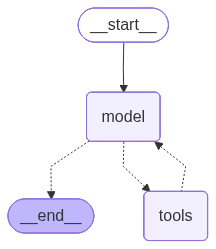

In [12]:
# ---------------------------------------------------
# SQL Assistant 그래프 시각화
# ---------------------------------------------------
# 그래프 흐름: START → agent → tools → agent → ... → END
# agent: SkillMiddleware가 스킬 설명을 시스템 프롬프트에 동적 주입해요
# tools: load_skill(스킬 로딩)과 execute_sql(SQL 실행) 도구를 실행해요
# load_skill은 Command를 반환하여 skills_loaded 상태를 업데이트해요
from IPython.display import Image, display

# 컴파일된 에이전트의 그래프 구조를 확인해요
display(Image(sql_assistant.get_graph().draw_mermaid_png()))

## 8. SQL Assistant 실행

이제 SQL Assistant를 실행해볼게요. 에이전트가 어떻게 스킬을 온디맨드로 로딩하는지 관찰해요.

> 🎯 **강의 포인트**: 실행 결과에서 **에이전트의 사고 과정**을 주목해주세요.
> 1. 첫 번째 호출: 스킬 설명만 보고 `load_skill('sql')` 호출 결정
> 2. 두 번째 호출: SQL 전문 지식이 주입된 후 정확한 쿼리 작성
> 3. `execute_sql` 호출 후 결과 해석

In [ ]:
# ---------------------------------------------------
# SQL Assistant 실행 - 월별 매출 조회
# ---------------------------------------------------
import uuid
from langchain.messages import HumanMessage
from langchain_core.runnables import RunnableConfig

# 실행 설정
config = RunnableConfig(
    recursion_limit=20,
    configurable={"thread_id": str(uuid.uuid4())}
)

# 사용자 요청: SQL 관련 작업
inputs = {
    "messages": [
        HumanMessage(
            content="완료된 주문의 월별 매출과 주문 건수를 알려주세요."
        )
    ]
}

# === SQL Assistant 실행 시작 ===
# 요청: 완료된 주문의 월별 매출과 주문 건수
# 예상 흐름: load_skill('sql') → SQL 작성 → execute_sql → 결과 해석
print()

for chunk in sql_assistant.stream(inputs, config, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- {node_name} ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                if hasattr(msg, "content") and msg.content:
                    # 긴 스킬 내용은 처음 300자만 표시
                    content = msg.content
                    if len(content) > 400:
                        content = content[:400] + "...(생략)"
                    msg_type = getattr(msg, "type", type(msg).__name__)
                    print(f"[{msg_type}] {content}")
        if "skills_loaded" in node_output:
            print(f"로딩된 스킬: {node_output['skills_loaded']}")

# === 실행 완료 ===

In [ ]:
# ---------------------------------------------------
# SQL Assistant 실행 - 분석 스킬도 활용
# ---------------------------------------------------
# 새 thread로 두 번째 대화 시작
config2 = RunnableConfig(
    recursion_limit=20,
    configurable={"thread_id": str(uuid.uuid4())}
)

inputs2 = {
    "messages": [
        HumanMessage(
            content=(
                "상위 3명의 고객을 조회하고, "
                "그들의 구매 패턴을 분석해서 비즈니스 인사이트를 보고서 형식으로 작성해주세요."
            )
        )
    ]
}

# === SQL Assistant 실행 - 분석 포함 ===
# 요청: 상위 고객 조회 + 분석 보고서
# 예상 흐름: load_skill('sql') → SQL 실행 → load_skill('analytics') → 보고서 작성
print()

for chunk in sql_assistant.stream(inputs2, config2, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- {node_name} ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                if hasattr(msg, "content") and msg.content:
                    content = msg.content
                    if len(content) > 500:
                        content = content[:500] + "...(생략)"
                    msg_type = getattr(msg, "type", type(msg).__name__)
                    print(f"[{msg_type}] {content}")
        if "skills_loaded" in node_output:
            print(f"현재 로딩된 스킬: {node_output['skills_loaded']}")

# === 실행 완료 ===

## 9. Skills Pattern vs. Subagents 패턴 비교

Skills Pattern과 Subagents 패턴을 성능 측면에서 비교해볼게요.

### 처리 흐름 비교

```mermaid
flowchart LR
    subgraph SUB["Subagents 패턴"]
        direction TB
        U1(["사용자"]) --> S(["Supervisor"])
        S --> A1(["SQL Agent<br>(독립 컨텍스트)"])
        S --> A2(["Analytics Agent<br>(독립 컨텍스트)"])
        A1 --> S
        A2 --> S
        S --> R1(["응답"])
    end

    subgraph SKL["Skills Pattern"]
        direction TB
        U2(["사용자"]) --> AG(["단일 에이전트"])
        AG -->|load_skill| SK1(["SQL 스킬<br>(컨텍스트 주입"])
        AG -->|load_skill| SK2(["Analytics 스킬<br>(컨텍스트 주입)"])
        SK1 --> AG
        SK2 --> AG
        AG --> R2(["응답"])
    end

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e

    class U1,U2 input
    class S,AG process
    class A1,A2,SK1,SK2 storage
    class R1,R2 output
```

### 성능 비교 (대표적 작업 기준)

| 지표 | Subagents 패턴 | Skills Pattern | 비고 |
|------|----------------|----------------|------|
| **LLM 호출 수** | ~5회 | ~3회 | Skills가 약 40% 적음 |
| **총 토큰** | ~9K | ~15K | Subagents가 더 적음 |
| **컨텍스트 연속성** | 에이전트별 분리 | 하나의 스레드 | Skills가 유리 |
| **결과 일관성** | 에이전트 간 전달 필요 | 단일 컨텍스트 | Skills가 유리 |
| **확장성** | 에이전트 추가 | 스킬 파일 추가 | 유사함 |

> 🔑 **핵심 개념**: Skills Pattern은 **LLM 호출 수를 줄이지만 단일 호출당 토큰이 늘어나요**. Subagents는 **토큰은 적지만 호출 수가 많아요**. 복잡한 추론이 필요하고 컨텍스트 연속성이 중요한 작업은 Skills Pattern이, 독립적인 병렬 작업이 많으면 Subagents가 유리해요.

> 💡 **실무 팁**: 스킬의 `content`가 매우 길어지면 토큰 비용이 급격히 증가해요. Progressive Disclosure의 핵심은 **필요한 스킬만, 필요할 때** 로딩하는 것이에요. `content`는 핵심 정보만 담고 간결하게 유지하세요.

## 10. 실습: 새 스킬 추가하기

아래 실습 해설 블록을 완성해 **이메일 작성 스킬**을 SQL Assistant에 추가해보세요.

이메일 스킬은 SQL 조회 결과를 바탕으로 고객에게 보낼 이메일 초안을 작성하는 전문 스킬이에요.

In [ ]:
# ============================================================
# 실습 해설: 이메일 작성 스킬 추가하기
# ============================================================

email_skill: Skill = {
    "name": "email",
    "description": "고객에게 보낼 비즈니스 이메일 초안을 작성할 때 사용해요.",
    "content": """
    이메일 작성 가이드라인:
    - 제목, 인사말, 본문, 마무리, 서명 순서로 작성한다.
    - 톤은 정중하고 따뜻한 비즈니스 한국어를 사용한다.
    - 고객 감사 이메일은 구체적인 감사 사유와 다음 행동을 함께 제안한다.
    - 과장된 표현보다 명확하고 신뢰감 있는 문장을 우선한다.
    """,
}

SKILLS_REGISTRY[email_skill["name"]] = email_skill

new_skill_middleware = SkillMiddleware(
    skills=[sql_skill, analytics_skill, email_skill]
)

enhanced_sql_assistant = create_agent(
    model,
    tools=[load_skill, execute_sql],
    system_prompt=system_prompt,
    state_schema=CustomState,
    middleware=[new_skill_middleware],
    checkpointer=MemorySaver(),
)

test_inputs = {
    "messages": [
        HumanMessage(
            content="가장 많이 구매한 상위 3명의 고객에게 감사 이메일 초안을 작성해주세요."
        )
    ]
}

result = enhanced_sql_assistant.invoke(
    test_inputs,
    config={"configurable": {"thread_id": "skills-email-demo"}},
)
print(result["messages"][-1].content)


## 11. 확장 패턴

Skills Pattern을 더 강력하게 활용하는 세 가지 확장 방식을 살펴볼게요.

In [16]:
# ---------------------------------------------------
# 확장 패턴 1: 동적 도구 등록
# ---------------------------------------------------
# 스킬 로딩 시 해당 스킬 전용 도구도 함께 등록하는 패턴이에요
# 예: sql 스킬 로딩 → execute_sql 도구 활성화

from langchain.tools import BaseTool


class DynamicSkillRegistry:
    """스킬과 도구를 함께 관리하는 동적 레지스트리예요

    스킬 로딩 시 해당 스킬 전용 도구도 함께 활성화할 수 있어요.
    """

    def __init__(self):
        # 스킬 이름 → (Skill, 도구 목록) 매핑
        self._registry: dict[str, tuple[Skill, list[BaseTool]]] = {}

    def register(self, skill: Skill, tools: list[BaseTool] = None):
        """스킬과 관련 도구를 등록해요"""
        self._registry[skill["name"]] = (skill, tools or [])

    def get_skill(self, name: str) -> Skill | None:
        """스킬 메타데이터를 반환해요"""
        entry = self._registry.get(name)
        return entry[0] if entry else None

    def get_tools(self, name: str) -> list[BaseTool]:
        """스킬 전용 도구 목록을 반환해요"""
        entry = self._registry.get(name)
        return entry[1] if entry else []

    @property
    def all_skills(self) -> list[Skill]:
        """등록된 모든 스킬 목록"""
        return [entry[0] for entry in self._registry.values()]


# 동적 레지스트리 사용 예시
dynamic_registry = DynamicSkillRegistry()
dynamic_registry.register(sql_skill, tools=[execute_sql])     # SQL 스킬 + execute_sql 도구
dynamic_registry.register(analytics_skill, tools=[])          # 분석 스킬 (도구 없음)

# 확장 패턴 1: 동적 도구 등록
print(f"  등록된 스킬: {[s['name'] for s in dynamic_registry.all_skills]}")
sql_tools = [t.name for t in dynamic_registry.get_tools('sql')]
print(f"  'sql' 스킬 전용 도구: {sql_tools}")
print()

# ---------------------------------------------------
# 확장 패턴 2: 계층적 스킬
# ---------------------------------------------------
# 스킬이 다른 스킬에 의존하는 계층 구조예요
# 예: 'reporting' 스킬을 로딩하려면 'analytics' 스킬이 먼저 로딩되어야 해요

reporting_skill: Skill = {
    "name": "reporting",
    "description": (
        "경영진용 보고서 작성 스킬. "
        "analytics 스킬 로딩 후 사용 가능해요. "
        "load_skill('reporting')으로 로딩하세요."
    ),
    "content": """
## 경영진 보고서 작성 스킬

### 보고서 구조
1. 한 페이지 요약 (Executive Summary): 핵심 수치 3개 이내
2. 상세 분석: 데이터 기반 근거
3. 전략적 제언: 구체적인 다음 액션

### 주의사항
- analytics 스킬의 KPI 공식을 반드시 활용하세요
- 수치는 이전 기간 대비 변화율(%)로 표현하세요
""",
}

# 확장 패턴 2: 계층적 스킬 예시
#   reporting 스킬은 analytics 스킬에 의존해요
#   로딩 순서: analytics → reporting
print()

# ---------------------------------------------------
# 확장 패턴 3: 참조 인식 (Reference-Aware)
# ---------------------------------------------------
# 스킬 content에 다른 스킬을 참조하는 마커를 넣어
# 에이전트가 연관 스킬도 자동으로 로딩하도록 유도해요

advanced_sql_skill: Skill = {
    "name": "advanced_sql",
    "description": (
        "고급 SQL 최적화 스킬 (기본 sql 스킬 필요). "
        "복잡한 JOIN, 서브쿼리, 성능 최적화가 필요할 때 사용해요."
    ),
    "content": """
## 고급 SQL 최적화 스킬

참조: 이 스킬은 기본 'sql' 스킬을 먼저 로딩해야 해요.

### 윈도우 함수 패턴
```sql
-- 누적 매출 계산
SELECT month, revenue,
       SUM(revenue) OVER (ORDER BY month) AS cumulative_revenue
FROM monthly_sales;
```

### CTE (Common Table Expression) 패턴
```sql
WITH ranked_customers AS (
    SELECT user_id, total_spent,
           RANK() OVER (ORDER BY total_spent DESC) AS rank
    FROM customer_summary
)
SELECT * FROM ranked_customers WHERE rank <= 10;
```
""",
}

# 확장 패턴 3: 참조 인식 스킬
#   advanced_sql 스킬은 content에 'sql 스킬 먼저 로딩' 안내 포함
#   에이전트가 content를 읽고 선행 스킬을 자동으로 로딩해요

  등록된 스킬: ['sql', 'analytics']
  'sql' 스킬 전용 도구: ['execute_sql']




## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **Progressive Disclosure(점진적 공개)**: 스킬의 `description`만 시스템 프롬프트에 포함하고, 상세 내용인 `content`는 `load_skill` 호출 시에만 주입해요. 토큰을 절약하면서도 필요한 전문성을 확보할 수 있어요.

- **Skill TypedDict**: `name`(식별자), `description`(항상 공개), `content`(온디맨드 로딩) 세 필드로 구성돼요. description은 짧고 명확하게, content에는 풍부한 전문 지식을 담아요.

- **SkillMiddleware**: `AgentMiddleware`를 상속하고 `wrap_model_call`을 오버라이드해요. LLM 호출 직전에 아직 로딩하지 않은 스킬의 설명을 시스템 프롬프트에 자동으로 추가해요.

- **load_skill + Command**: 일반 도구와 달리 `Command`를 반환해 `CustomState`의 `skills_loaded`를 직접 업데이트해요. `InjectedToolCallId`로 올바른 `ToolMessage`를 생성할 수 있어요.

- **CustomState**: `AgentState`를 상속하고 `skills_loaded: Annotated[list[str], operator.add]`를 추가해요. `operator.add` 리듀서가 여러 스텝에서의 동시 업데이트를 안전하게 병합해줘요. 중복 스킬 로딩 방지와 미들웨어의 스킬 설명 제거에 활용돼요.

- **Skills vs. Subagents**: Skills Pattern은 LLM 호출 수가 적고 컨텍스트 연속성이 우수해요. Subagents는 토큰 효율이 높고 병렬 작업에 강해요. 작업 특성에 맞게 선택하세요.

- **하네스 관점**: Skills는 필요한 지식을 온디맨드로 주입하는 Inform 계층이며, 잘 설계된 description은 모델이 잘못된 절차를 선택하지 않도록 돕는 가벼운 Constrain 역할도 해요.

## 다음 노트북 예고

다음 `08-Hierarchical-Agent.ipynb`에서는 **계층적 에이전트(Hierarchical Agent)**를 배워요. Supervisor가 하위 Supervisor를 거느리고, 그 하위 Supervisor가 Worker를 관리하는 **조직도 구조**예요. 팀이 여럿인 대규모 작업(예: 리서치팀 + 작성팀 + 검토팀)을 한 번에 조율할 때 사용해요. Part 09의 마지막 레슨으로, 이후 Part 10에서는 이 복잡한 오케스트레이션을 자동화한 **Deep Agents 하네스**로 넘어가요.